# Создание дашборда для аналитики League of Legends

Автор: Стукалов Артем Витальевич  
Дата: 05.07.2026

Импортируем библиотеки

In [12]:
import pandas as pd
import plotly.express as px
import numpy as np
import webbrowser
import os

Загрузим ранее полученные csv файлы

In [2]:
# Загружаем датасет final_df из CSV
final_df = pd.read_csv("final_data.csv")

# Добавляем длительность в минутах
final_df["game_duration_min"] = final_df["game_duration_sec"] / 60

# Добавляем KDA в final_df
final_df["kda"] = (final_df["kills"] + final_df["assists"]) / final_df["deaths"].replace(0, 1)

Создадим график топ чемпионов по винрейту

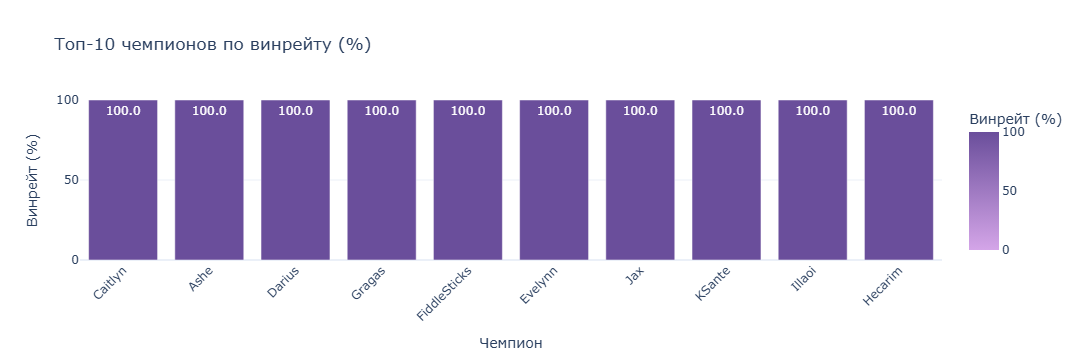

In [3]:
# График топ-10 чемпионов по винрейту
top_winrate = final_df.groupby("champion")["win"].mean().sort_values(ascending=False).head(10).reset_index()
top_winrate["win"] = top_winrate["win"] * 100

fig_winrate = px.bar(
    top_winrate,
    x="champion",
    y="win",
    title="Топ-10 чемпионов по винрейту (%)",
    labels={"win": "Винрейт (%)", "champion": "Чемпион"},
    color="win",
    color_continuous_scale=["#D4A5E8", "#6A4E9B"],
    text_auto=".1f",
    range_y=[0, 100],
    range_color=[0, 100]
)
fig_winrate.update_layout(template="plotly_white", xaxis_tickangle=-45)

Создадим график топ чемпионов по LP.

In [4]:
# График топ чемпионов по LP
top_lp = final_df.groupby("champion")["leaguePoints"].sum().sort_values(ascending=False).head(10).reset_index()
fig_lp = px.bar(
    top_lp, 
    x="champion", 
    y="leaguePoints", 
    title="Топ-10 чемпионов по суммарному LP",
    labels={"leaguePoints": "Суммарное LP", "champion": "Чемпион"},
    color="leaguePoints",
    color_continuous_scale=["#D4A5E8", "#6A4E9B"],
    text_auto=True
)
fig_lp.update_layout(xaxis_tickangle=-45, template="plotly_white")

Создадим гистограмму распределения LP

In [5]:
# Строим гистограмму распределния LP
lp_spread_fig = px.histogram(
    final_df,
    x="leaguePoints",
    title="Распределение LP игроков",
    labels={"leaguePoints": "LP", "count": "Количество игроков"},
    nbins=20,
    color_discrete_sequence=["#5B8CB8"]  # один цвет
)
lp_spread_fig.update_layout(template="plotly_white")

Визуализируем длительность матчей

In [6]:
# Строим диаграмму размаха длительности матчей
match_duration_spread = px.box(
    final_df,
    y="game_duration_min",
    title="Длительность матчей (минуты)",
    labels={"game_duration_min": "Длительность (мин)"},
    points="all",
    color_discrete_sequence=["#5B8CB8"]
)
match_duration_spread.update_layout(template="plotly_white")

Выясним зависимость средних убийств от смертей по чемпионам.

In [7]:
# Построим Scatter-plot зависимости средних убийств от смертей по чемпионам
avg_stats = final_df.groupby("champion").agg(
    avg_kills=("kills", "mean"),
    avg_deaths=("deaths", "mean"),
    count=("champion", "count")
).reset_index()

avg_stats = avg_stats[avg_stats["count"] >= 3]

fig_avg_stats = px.scatter(
    avg_stats,
    x="avg_kills",
    y="avg_deaths",
    hover_data=["champion", "count"],
    title="Средние убийства vs смерти по чемпионам",
    labels={"avg_kills": "Средние убийства", "avg_deaths": "Средние смерти"},
    size="count",
    color="count",
    color_continuous_scale=["#B8D4E8", "#4A7A9E"],  # от бледно-голубого к тёмно-синему
    trendline="ols"
)
fig_avg_stats.update_layout(template="plotly_white")

Формируем HTML код

In [8]:
html_content = """
<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>League of Legends - Дашборд</title>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { 
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }
        .container { 
            max-width: 1300px; 
            margin: 0 auto; 
            background: white;
            border-radius: 20px;
            padding: 30px;
            box-shadow: 0 20px 60px rgba(0,0,0,0.3);
        }
        h1 { 
            text-align: center; 
            color: #2c3e50;
            font-size: 2.5em;
            margin-bottom: 10px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
            background-clip: text;
        }
        .subtitle {
            text-align: center;
            color: #7f8c8d;
            margin-bottom: 30px;
            font-size: 1.1em;
        }
        .graph { 
            background: #f8f9fa;
            padding: 20px; 
            margin: 30px 0; 
            border-radius: 15px; 
            box-shadow: 0 2px 15px rgba(0,0,0,0.08);
            transition: transform 0.3s ease;
        }
        .graph:hover {
            transform: translateY(-5px);
            box-shadow: 0 5px 25px rgba(0,0,0,0.12);
        }
        .graph-title {
            font-size: 1.2em;
            color: #34495e;
            margin-bottom: 15px;
            padding-left: 10px;
            border-left: 4px solid #667eea;
        }
        .footer {
            text-align: center;
            margin-top: 30px;
            padding-top: 20px;
            border-top: 2px solid #ecf0f1;
            color: #95a5a6;
        }
        @media (max-width: 768px) {
            .container { padding: 15px; }
            h1 { font-size: 1.8em; }
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>🏆 League of Legends</h1>
        <p class="subtitle">Региональный дашборд по чемпионам и матчам (EUW)</p>
"""

# Добавляем графики
html_content += '<div class="graph"><div class="graph-title">📊 Топ-10 чемпионов по винрейту</div>'
html_content += fig_winrate.to_html(full_html=False, include_plotlyjs='cdn')
html_content += '</div>'

html_content += '<div class="graph"><div class="graph-title">🏅 Топ-10 чемпионов по суммарному LP</div>'
html_content += fig_lp.to_html(full_html=False, include_plotlyjs=False)
html_content += '</div>'

html_content += '<div class="graph"><div class="graph-title">📈 Распределение LP игроков</div>'
html_content += lp_spread_fig.to_html(full_html=False, include_plotlyjs=False)
html_content += '</div>'

html_content += '<div class="graph"><div class="graph-title">⏱️ Длительность матчей (диаграмма размаха)</div>'
html_content += match_duration_spread.to_html(full_html=False, include_plotlyjs=False)
html_content += '</div>'

html_content += '<div class="graph"><div class="graph-title">⚔️ Средние убийства vs смерти по чемпионам</div>'
html_content += fig_avg_stats.to_html(full_html=False, include_plotlyjs=False)
html_content += '</div>'

html_content += """
        <div class="footer">
            <p>📅 Данные обновлены: EUW (регион)</p>
            <p style="font-size: 0.9em; margin-top: 5px;">Создано с помощью Plotly & Dash</p>
        </div>
    </div>
</body>
</html>
"""

Сохраним дашборд в jupyter notebook и откроем его в браузере

In [13]:
# Сохраняем в текущую папку
file_name = "dashboard.html"
with open(file_name, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Дашборд сохранён как {file_name}")
print(f"Полный путь: {os.path.abspath(file_name)}")

# Открываем в браузере
webbrowser.open(file_name)
print("Дашборд открыт в браузере")

Дашборд сохранён как dashboard.html
Полный путь: C:\Users\Honor\AppData\Local\Programs\Python\Python313\Scripts\League Of Legends\dashboard.html
Дашборд открыт в браузере
